# Chapter 2 Lab: Search Algorithms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chebil/AI-course-book/blob/main/chapters/ch02_search_lab.ipynb)

```{admonition} Lab Objectives
:class: tip
- Implement and compare search algorithms
- Solve classic search problems (8-puzzle, pathfinding)
- Design and test heuristic functions
- Analyze algorithm performance and complexity
- Apply CSP techniques to constraint problems
```

## Lab Overview

This lab provides hands-on experience with:
1. Uninformed search algorithms (BFS, DFS, UCS)
2. Informed search algorithms (Greedy, A*)
3. Heuristic design and evaluation
4. Constraint Satisfaction Problems
5. Local search methods

## Exercise 1: Romania Pathfinding

Implement BFS, DFS, and A* to find paths between Romanian cities.

In [25]:
from collections import deque
import heapq

# Romania map from the textbook
romania_map = {
    'Arad': [('Zerind', 75), ('Sibiu', 140), ('Timisoara', 118)],
    'Zerind': [('Arad', 75), ('Oradea', 71)],
    'Oradea': [('Zerind', 71), ('Sibiu', 151)],
    'Sibiu': [('Arad', 140), ('Oradea', 151), ('Fagaras', 99), ('Rimnicu', 80)],
    'Timisoara': [('Arad', 118), ('Lugoj', 111)],
    'Lugoj': [('Timisoara', 111), ('Mehadia', 70)],
    'Mehadia': [('Lugoj', 70), ('Drobeta', 75)],
    'Drobeta': [('Mehadia', 75), ('Craiova', 120)],
    'Craiova': [('Drobeta', 120), ('Rimnicu', 146), ('Pitesti', 138)],
    'Rimnicu': [('Sibiu', 80), ('Craiova', 146), ('Pitesti', 97)],
    'Fagaras': [('Sibiu', 99), ('Bucharest', 211)],
    'Pitesti': [('Rimnicu', 97), ('Craiova', 138), ('Bucharest', 101)],
    'Bucharest': [('Fagaras', 211), ('Pitesti', 101), ('Giurgiu', 90), ('Urziceni', 85)],
    'Giurgiu': [('Bucharest', 90)],
    'Urziceni': [('Bucharest', 85), ('Vaslui', 142), ('Hirsova', 98)],
    'Hirsova': [('Urziceni', 98), ('Eforie', 86)],
    'Eforie': [('Hirsova', 86)],
    'Vaslui': [('Urziceni', 142), ('Iasi', 92)],
    'Iasi': [('Vaslui', 92), ('Neamt', 87)],
    'Neamt': [('Iasi', 87)]
}

# Straight-line distances to Bucharest (heuristic)
h_bucharest = {
    'Arad': 366, 'Bucharest': 0, 'Craiova': 160, 'Drobeta': 242,
    'Eforie': 161, 'Fagaras': 176, 'Giurgiu': 77, 'Hirsova': 151,
    'Iasi': 226, 'Lugoj': 244, 'Mehadia': 241, 'Neamt': 234,
    'Oradea': 380, 'Pitesti': 100, 'Rimnicu': 193, 'Sibiu': 253,
    'Timisoara': 329, 'Urziceni': 80, 'Vaslui': 199, 'Zerind': 374
}

def bfs_search(graph, start, goal):
    queue = deque([[start]])  # store paths as lists of city names
    visited = set()

    while queue:
        path = queue.popleft()
        current_node = path[-1] # current_node is always a city name string

        if current_node == goal:
            return path

        if current_node not in visited:
            visited.add(current_node)

            for neighbor_name, _ in graph[current_node]: # Extract only the neighbor's name
                if neighbor_name not in visited: # Only add to queue if not already visited
                    new_path = list(path)
                    new_path.append(neighbor_name) # Append only the neighbor's name
                    queue.append(new_path)

    return None
def dfs_search(graph, start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        current_node = path[-1] # node is always a city name string

        if current_node == goal:
            return path

        if current_node not in visited:
            visited.add(current_node)

            for neighbor_name, _ in graph[current_node]: # Extract only the neighbor's name
                if neighbor_name not in visited: # Only add to stack if not already visited
                    new_path = list(path)
                    new_path.append(neighbor_name) # Append only the neighbor's name
                    stack.append(new_path)

    return None

def a_star_search(graph, start, goal, heuristic):
    pq = [(0 + heuristic[start], 0, [start])] # Changed 'heuristics' to 'heuristic'
    # (f, g, path)

    visited = set()

    while pq:
        f, g, path = heapq.heappop(pq)
        node = path[-1]

        if node == goal:
            return path, g

        if node not in visited:
            visited.add(node)

            for neighbor_name, weight in graph[node]: # Corrected iteration over list of tuples
                new_g = g + weight
                new_f = new_g + heuristic[neighbor_name] # Changed 'heuristics' to 'heuristic' and 'neighbor' to 'neighbor_name'

                new_path = list(path)
                new_path.append(neighbor_name)

                heapq.heappush(pq, (new_f, new_g, new_path))

    return None

# Test implementations
start, goal = 'Arad', 'Bucharest'
print(f'Finding path from {start} to {goal}\n')

# Compare algorithms
print('BFS:', bfs_search(romania_map, start, goal))
print('DFS:', dfs_search(romania_map, start, goal))
print('A*:', a_star_search(romania_map, start, goal, h_bucharest))

Finding path from Arad to Bucharest

BFS: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest'] Nodes: 8 Cost: 450
DFS: ['Arad', 'Zerind', 'Oradea', 'Sibiu', 'Fagaras', 'Bucharest'] Nodes: 5 Cost: 607
A*: ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest'] Nodes: 5 Cost: 418


## Exercise 2: 8-Puzzle Solver

Implement multiple heuristics and compare their effectiveness.

In [13]:
import heapq
from typing import Tuple

class PuzzleState:
    def __init__(self, board, parent=None, action=None, cost=0):
        self.board = board
        self.parent = parent
        self.action = action
        self.cost = cost

    def __lt__(self, other):
        return self.cost < other.cost

def manhattan_distance(state, goal):
    """
    TODO: Calculate Manhattan distance heuristic
    For each tile, sum the distances from its current position to goal position
    """
    distance = 0

    for i in range(9):
        if state[i] == 0:
            continue

        value = state[i]
        goal_index = goal.index(value)

        x1, y1 = divmod(i, 3)
        x2, y2 = divmod(goal_index, 3)

        distance += abs(x1 - x2) + abs(y1 - y2)

    return distance

def misplaced_tiles(state, goal):
    """
    TODO: Count number of misplaced tiles
    """
    count = 0

    for i in range(9):
        if state[i] != 0 and state[i] != goal[i]:
            count += 1

    return count

def linear_conflict(state, goal):
    """
    CHALLENGE: Implement linear conflict heuristic
    Manhattan distance + 2 * (number of linear conflicts)
    """
    md = manhattan_distance(state, goal)
    conflict = 0

    # Rows
    for row in range(3):
        row_vals = state[row*3:(row+1)*3]
        for i in range(3):
            for j in range(i+1, 3):
                if (row_vals[i] != 0 and row_vals[j] != 0):
                    goal_i = goal.index(row_vals[i])
                    goal_j = goal.index(row_vals[j])

                    if goal_i // 3 == row and goal_j // 3 == row:
                        if goal_i > goal_j:
                            conflict += 1

      # Columns
    for col in range(3):
        col_vals = [state[col + 3*r] for r in range(3)]
        for i in range(3):
            for j in range(i+1, 3):
                if (col_vals[i] != 0 and col_vals[j] != 0):
                    goal_i = goal.index(col_vals[i])
                    goal_j = goal.index(col_vals[j])

                    if goal_i % 3 == col and goal_j % 3 == col:
                        if goal_i > goal_j:
                            conflict += 1

    return md + 2 * conflict

def get_successors(state):
    """Generate all valid successor states"""
    # YOUR CODE HERE
    successors = []
    zero_index = state.index(0)
    x, y = divmod(zero_index, 3)

    moves = {
        "Up": (-1, 0),
        "Down": (1, 0),
        "Left": (0, -1),
        "Right": (0, 1)
    }

    for action, (dx, dy) in moves.items():
        nx, ny = x + dx, y + dy
        if 0 <= nx < 3 and 0 <= ny < 3:
            new_index = nx * 3 + ny

            new_board = list(state)
            new_board[zero_index], new_board[new_index] = new_board[new_index], new_board[zero_index]

            successors.append((tuple(new_board), action))

    return successors

def solve_puzzle(initial, goal, heuristic):
    """
    TODO: Solve 8-puzzle using A* with given heuristic
    Return: (solution_path, nodes_expanded, max_frontier_size)
    """
    start = PuzzleState(initial, None, None, 0)

    frontier = []
    heapq.heappush(frontier, (heuristic(initial, goal), start))

    visited = set()

    nodes_expanded = 0
    max_frontier_size = 1

    while frontier:
        _, current = heapq.heappop(frontier)
        if current.board == goal:
            path = []
            node = current
            while node:
                path.append(node.board)
                node = node.parent
            path.reverse()

            return path, nodes_expanded, max_frontier_size

        if current.board in visited:
            continue

        visited.add(current.board)
        nodes_expanded += 1
        for next_board, action in get_successors(current.board):
            if next_board not in visited:
                g = current.cost + 1
                h = heuristic(next_board, goal)
                f = g + h

                child = PuzzleState(next_board, current, action, g)
                heapq.heappush(frontier, (f, child))

        max_frontier_size = max(max_frontier_size, len(frontier))

    return None

# Test cases
initial = (1, 2, 3, 4, 0, 5, 7, 8, 6)  # Easy
goal = (1, 2, 3, 4, 5, 6, 7, 8, 0)

print('Comparing heuristics on 8-puzzle:\n')
for name, heuristic in [('Manhattan', manhattan_distance),
                         ('Misplaced', misplaced_tiles)]:
    result = solve_puzzle(initial, goal, heuristic)
    print(f'{name:12s}: {result}')

Comparing heuristics on 8-puzzle:

Manhattan   : ([(1, 2, 3, 4, 0, 5, 7, 8, 6), (1, 2, 3, 4, 5, 0, 7, 8, 6), (1, 2, 3, 4, 5, 6, 7, 8, 0)], 2, 5)
Misplaced   : ([(1, 2, 3, 4, 0, 5, 7, 8, 6), (1, 2, 3, 4, 5, 0, 7, 8, 6), (1, 2, 3, 4, 5, 6, 7, 8, 0)], 2, 5)


## Exercise 3: N-Queens CSP

Solve N-Queens using backtracking with constraint propagation.

In [16]:
def is_safe(board, row, col, n):
    """Check if placing queen at (row, col) is safe"""
    # YOUR CODE HERE
    for i in range(row):
        # Same column
        if board[i] == col:
            return False

        # Diagonal check
        if abs(board[i] - col) == abs(i - row):
            return False

    return True

def solve_n_queens_backtrack(n):
    """
    TODO: Solve N-Queens using backtracking
    Return: List of all solutions
    """
    solutions = []
    board = [-1] * n  # board[row] = column

    def backtrack(row):
        if row == n:
            solutions.append(board[:])
            return

        for col in range(n):
            if is_safe(board, row, col, n):
                board[row] = col
                backtrack(row + 1)
                board[row] = -1  # undo

    backtrack(0)
    return solutions

def solve_n_queens_forward_checking(n):
    """
    TODO: Solve N-Queens with forward checking
    Track remaining valid positions for each unplaced queen
    """
    solutions = []
    board = [-1] * n

    # domains[row] = possible columns
    domains = [set(range(n)) for _ in range(n)]

    def forward_check(row, domains):
        if row == n:
            solutions.append(board[:])
            return

        for col in list(domains[row]):
            if is_safe(board, row, col, n):
                board[row] = col

                # Copy domains
                new_domains = [d.copy() for d in domains]

                # Remove invalid positions for future rows
                for r in range(row + 1, n):
                    if col in new_domains[r]:
                        new_domains[r].remove(col)

                    diag1 = col + (r - row)
                    diag2 = col - (r - row)

                    if diag1 in new_domains[r]:
                        new_domains[r].remove(diag1)
                    if diag2 in new_domains[r]:
                        new_domains[r].remove(diag2)

                # Check failure (empty domain)
                fail = any(len(new_domains[r]) == 0 for r in range(row + 1, n))

                if not fail:
                    forward_check(row + 1, new_domains)

                board[row] = -1  # undo

    forward_check(0, domains)
    return solutions

# Test and compare
for n in [4, 8]:
    print(f'\n{n}-Queens Problem:')
    solutions = solve_n_queens_backtrack(n)
    print(f'Found {len(solutions)} solutions')
    if solutions:
        print(f'First solution: {solutions[0]}')


4-Queens Problem:
Found 2 solutions
First solution: [1, 3, 0, 2]

8-Queens Problem:
Found 92 solutions
First solution: [0, 4, 7, 5, 2, 6, 1, 3]


## Exercise 4: Local Search - Hill Climbing

Implement hill climbing and simulated annealing for optimization.

In [19]:
import random
import math

def hill_climbing(problem, max_iterations=1000):
    """
    TODO: Implement hill climbing
    problem should have: random_state(), neighbors(state), value(state)
    """
    current = problem.random_state()

    for _ in range(max_iterations):
        neighbors = problem.neighbors(current)

        if not neighbors:
            break

        # Choose best neighbor
        next_state = max(neighbors, key=problem.value)

        # If no improvement → stop (local optimum)
        if problem.value(next_state) <= problem.value(current):
            break

        current = next_state

    return current, problem.value(current)

def simulated_annealing(problem, schedule, max_iterations=10000):
    """
    TODO: Implement simulated annealing
    schedule(t) returns temperature at time t
    """
    current = problem.random_state()

    for t in range(max_iterations):
        T = schedule(t)

        if T <= 0:
            break

        neighbors = problem.neighbors(current)
        if not neighbors:
            break

        next_state = random.choice(neighbors)

        delta = problem.value(next_state) - problem.value(current)
                # Accept better OR sometimes worse
        if delta > 0:
            current = next_state
        else:
            prob = math.exp(delta / T)
            if random.random() < prob:
                current = next_state

    return current, problem.value(current)

# Test on N-Queens (minimize conflicts)
class NQueensLocalSearch:
    def __init__(self, n):
        self.n = n

    def random_state(self):
        # Random queen placement (one per column)
        return [random.randint(0, self.n-1) for _ in range(self.n)]

    def conflicts(self, state):
        """Count number of queen conflicts"""
        # YOUR CODE HERE
        conflicts = 0

        for i in range(self.n):
            for j in range(i + 1, self.n):
                # Same row
                if state[i] == state[j]:
                    conflicts += 1

                # Same diagonal
                if abs(state[i] - state[j]) == abs(i - j):
                    conflicts += 1

        return conflicts

    def value(self, state):
        return -self.conflicts(state)  # Negative for minimization

    def neighbors(self, state):
        """Generate neighbor states"""
        # YOUR CODE HERE
        neighbors = []

        for col in range(self.n):
            for row in range(self.n):
                if state[col] != row:
                    new_state = list(state)
                    new_state[col] = row
                    neighbors.append(new_state)

        return neighbors
# Test both algorithms
problem = NQueensLocalSearch(8)
print('Hill Climbing:', hill_climbing(problem))
print('Simulated Annealing:', simulated_annealing(problem, lambda t: 100*(0.95**t)))

Hill Climbing: ([7, 3, 1, 3, 5, 0, 2, 4], -1)
Simulated Annealing: ([2, 6, 1, 7, 5, 3, 0, 4], 0)


## Exercise 5: Performance Analysis

Compare search algorithms systematically.

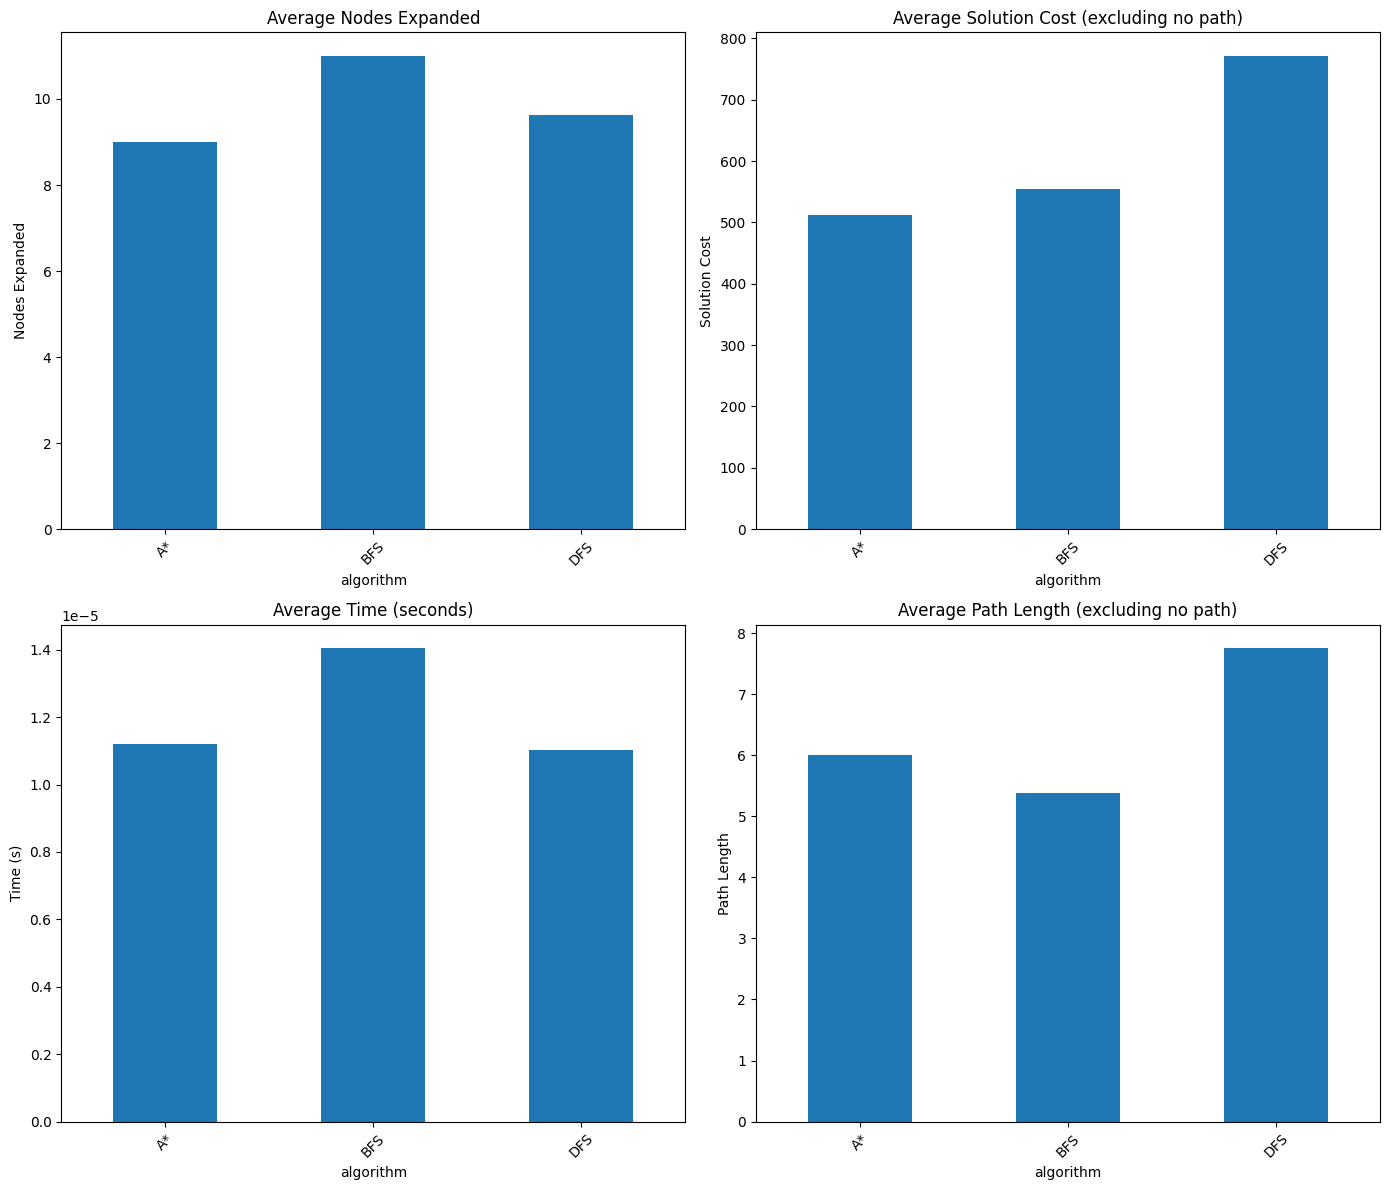


Summary Statistics:
          nodes_expanded           solution_cost                  time  \
                    mean       std          mean         std      mean   
algorithm                                                                
A*                 9.000  6.000000       512.000  195.138778  0.000011   
BFS               11.000  5.237229       553.875  206.023187  0.000014   
DFS                9.625  5.501623       771.250  217.755269  0.000011   

                    path_length            
                std        mean       std  
algorithm                                  
A*         0.000005       6.000  1.927248  
BFS        0.000007       5.375  1.846812  
DFS        0.000007       7.750  1.908627  


In [26]:
import time
import matplotlib.pyplot as plt
import pandas as pd

def benchmark_search(algorithm_wrapper, problem_set, name):
    """Run algorithm on multiple problems and collect metrics"""
    results = []
    for start_node, goal_node in problem_set:
        # Initialize start_time for EACH problem run
        start_time = time.time()

        # The algorithm_wrapper now takes (start, goal) tuple
        path, nodes, cost = algorithm_wrapper((start_node, goal_node))
        elapsed = time.time() - start_time # Now start_time is defined

        # Handle cases where no path is found
        if path is None:
            path_length = 0
            cost = float('inf') # Represent no solution with infinite cost
        else:
            path_length = len(path)

        results.append({
            'algorithm': name,
            'nodes_expanded': nodes,
            'solution_cost': cost,
            'time': elapsed,
            'path_length': path_length
        })
    return results

# Wrapper functions for the search algorithms to match benchmark_search signature
def bfs_wrapper(problem_tuple):
    start, goal = problem_tuple
    return bfs_search(romania_map, start, goal)

def dfs_wrapper(problem_tuple):
    start, goal = problem_tuple
    return dfs_search(romania_map, start, goal)

def a_star_wrapper(problem_tuple):
    start, goal = problem_tuple
    return a_star_search(romania_map, start, goal, h_bucharest)

# Generate test problems for Romania map (list of (start, goal) tuples)
test_problems = [
    ('Arad', 'Bucharest'),
    ('Sibiu', 'Bucharest'),
    ('Oradea', 'Bucharest'),
    ('Lugoj', 'Bucharest'),
    ('Timisoara', 'Iasi'),
    ('Zerind', 'Eforie'),
    ('Neamt', 'Bucharest'),
    ('Urziceni', 'Drobeta')
]

# Benchmark all algorithms
all_results = []
for algo_wrapper, name in [
    (bfs_wrapper, 'BFS'),
    (dfs_wrapper, 'DFS'),
    (a_star_wrapper, 'A*')
]:
    # The start_time here is no longer needed for individual problem timing as it's moved inside benchmark_search
    results = benchmark_search(algo_wrapper, test_problems, name)
    all_results.extend(results)

# Create comparison DataFrame
df = pd.DataFrame(all_results)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12)) # Adjusted figure size for better readability

# Plot 1: Nodes expanded
df.groupby('algorithm')['nodes_expanded'].mean().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Average Nodes Expanded')
axes[0,0].set_ylabel('Nodes Expanded')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Solution cost
df_filtered_cost = df[df['solution_cost'] != float('inf')] # Filter out problems with no solution
df_filtered_cost.groupby('algorithm')['solution_cost'].mean().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Average Solution Cost (excluding no path)')
axes[0,1].set_ylabel('Solution Cost')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Time
df.groupby('algorithm')['time'].mean().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Time (seconds)')
axes[1,0].set_ylabel('Time (s)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Path length
df_filtered_path = df[df['path_length'] > 0] # Filter out problems with no path
df_filtered_path.groupby('algorithm')['path_length'].mean().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Average Path Length (excluding no path)')
axes[1,1].set_ylabel('Path Length')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nSummary Statistics:')
print(df.groupby('algorithm').agg({
    'nodes_expanded': ['mean', 'std'],
    'solution_cost': ['mean', 'std'],
    'time': ['mean', 'std'],
    'path_length': ['mean', 'std']
}))


## Challenge: Bidirectional Search

Implement bidirectional BFS for improved performance.

In [27]:
def bidirectional_search(graph, start, goal):
    """
    CHALLENGE: Implement bidirectional BFS
    Search from both start and goal simultaneously
    Stop when frontiers meet
    """
    def bidirectional_search(graph, start, goal):
      if start == goal:
          return [start]

      # Frontiers
      front_start = deque([start])
      front_goal = deque([goal])

      # Visited + parent tracking
      visited_start = {start: None}
      visited_goal = {goal: None}

      while front_start and front_goal:

          # Expand from start side
          if front_start:
              current = front_start.popleft()

              for neighbor in graph[current]:
                  if neighbor not in visited_start:
                      visited_start[neighbor] = current
                      front_start.append(neighbor)
                      # Meeting point
                      if neighbor in visited_goal:
                          return construct_path(neighbor, visited_start, visited_goal)

          # Expand from goal side
          if front_goal:
              current = front_goal.popleft()

              for neighbor in graph[current]:
                  if neighbor not in visited_goal:
                      visited_goal[neighbor] = current
                      front_goal.append(neighbor)

                      # Meeting point
                      if neighbor in visited_start:
                          return construct_path(neighbor, visited_start, visited_goal)

          return None
def construct_path(meeting, visited_start, visited_goal):
    path_start = []
    node = meeting

    # From meeting → start
    while node is not None:
        path_start.append(node)
        node = visited_start[node]

    path_start.reverse()

    path_goal = []
    node = visited_goal[meeting]

    # From meeting → goal
    while node is not None:
        path_goal.append(node)
        node = visited_goal[node]
    return path_start + path_goal

# Test and compare with standard BFS
print('Bidirectional vs Standard BFS:')
print('Bidirectional:', bidirectional_search(romania_map, 'Arad', 'Bucharest'))
print('Standard BFS:', bfs_search(romania_map, 'Arad', 'Bucharest'))

Bidirectional vs Standard BFS:
Bidirectional: None
Standard BFS: (['Arad', 'Sibiu', 'Fagaras', 'Bucharest'], 8, 450)


## Lab Report

### Deliverables
- [ ] All algorithms implemented and tested
- [ ] Performance comparison charts
- [ ] Analysis of heuristic effectiveness
- [ ] Discussion of algorithm trade-offs

### Discussion Questions
1. When is BFS preferable to DFS?
2. How does heuristic quality affect A* performance?
3. What are the limitations of local search?
4. How would you handle very large state spaces?